# PROJECT: Credit Card Customer Segmentation
## Business Objective:
A bank wants to segment its credit card customers to:
* Identify high-value customers
* Detect inactive/churn-risk users
* Personalize offers
* Optimize marketing strategies

## ML Objective:
Use clustering algorithms to group customers based on:
* Spending behavior
* Transaction patterns
* Credit utilization
* Engagement level

## Learning Goals
- Understand clustering
- Apply K-Means, DBSCAN, Agglomerative Clustering
- Use Elbow Method
- Interpret clusters for business decisions

## Step 1: Import Dependencies

In [1]:
# IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib

## 1. Problem Statement

Banks have large customer bases but lack clear segmentation.

This project aims to cluster customers into meaningful groups
based on behavioral and financial features.

## 2. Data Understanding

In pandas, CSV (Comma-Separated Values) files are preferred over Excel (.xlsx, .xls) files primarily because they are plain text, lightweight, and significantly faster to read and write.

In [2]:
#Load dataset
dataset = pd.read_csv(r"C:\Users\murja\Desktop\AI_ML001\3Logy-NDI-AI-ML-Crash\datasets\Credit_Card_Customer\BankChurners.csv")
dataset.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  str    
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                                      

## IDENTIFY IMPORTANT FEATURES
To identify important features, let's Start With Business Understanding (ALWAYS FIRST).
Before touching code, ask:

> “What behaviors define a credit card customer?”

Let's think in **business dimensions**:

| Concept    | Meaning                |
| ---------- | ---------------------- |
| Spending   | How much money is used |
| Frequency  | How often card is used |
| Capacity   | Financial strength     |
| Risk       | Likelihood of churn    |
| Engagement | Activity level         |

This step is called:
**Feature relevance through domain understanding**

In [4]:
# Map Dataset Features to Business Meaning by inspecting column names:\
dataset.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='str')

## Interpretation of cloumns

| Feature                | Student Reasoning                        |
| ---------------------- | ---------------------------------------- |
| Total_Trans_Amt        | “Total amount spent → spending behavior” |
| Total_Trans_Ct         | “Number of transactions → activity”      |
| Credit_Limit           | “Maximum credit → capacity”              |
| Avg_Utilization_Ratio  | “How much of credit is used → behavior”  |
| Months_Inactive_12_mon | “Inactivity → engagement/churn risk”     |

This step is: **Feature semantic mapping**

Ask yourself:

> “If you were the bank, which variables would YOU care about?”

## 3. Exploratory Data Analysis (EDA)

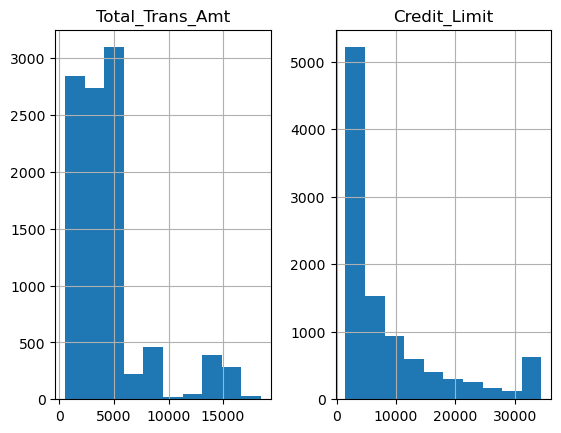

In [5]:
# A. Distribution Analysis
dataset[['Total_Trans_Amt', 'Credit_Limit']].hist();

Ask:
* Which features vary a lot?
* Which ones separate customers?

In [6]:
dataset.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990


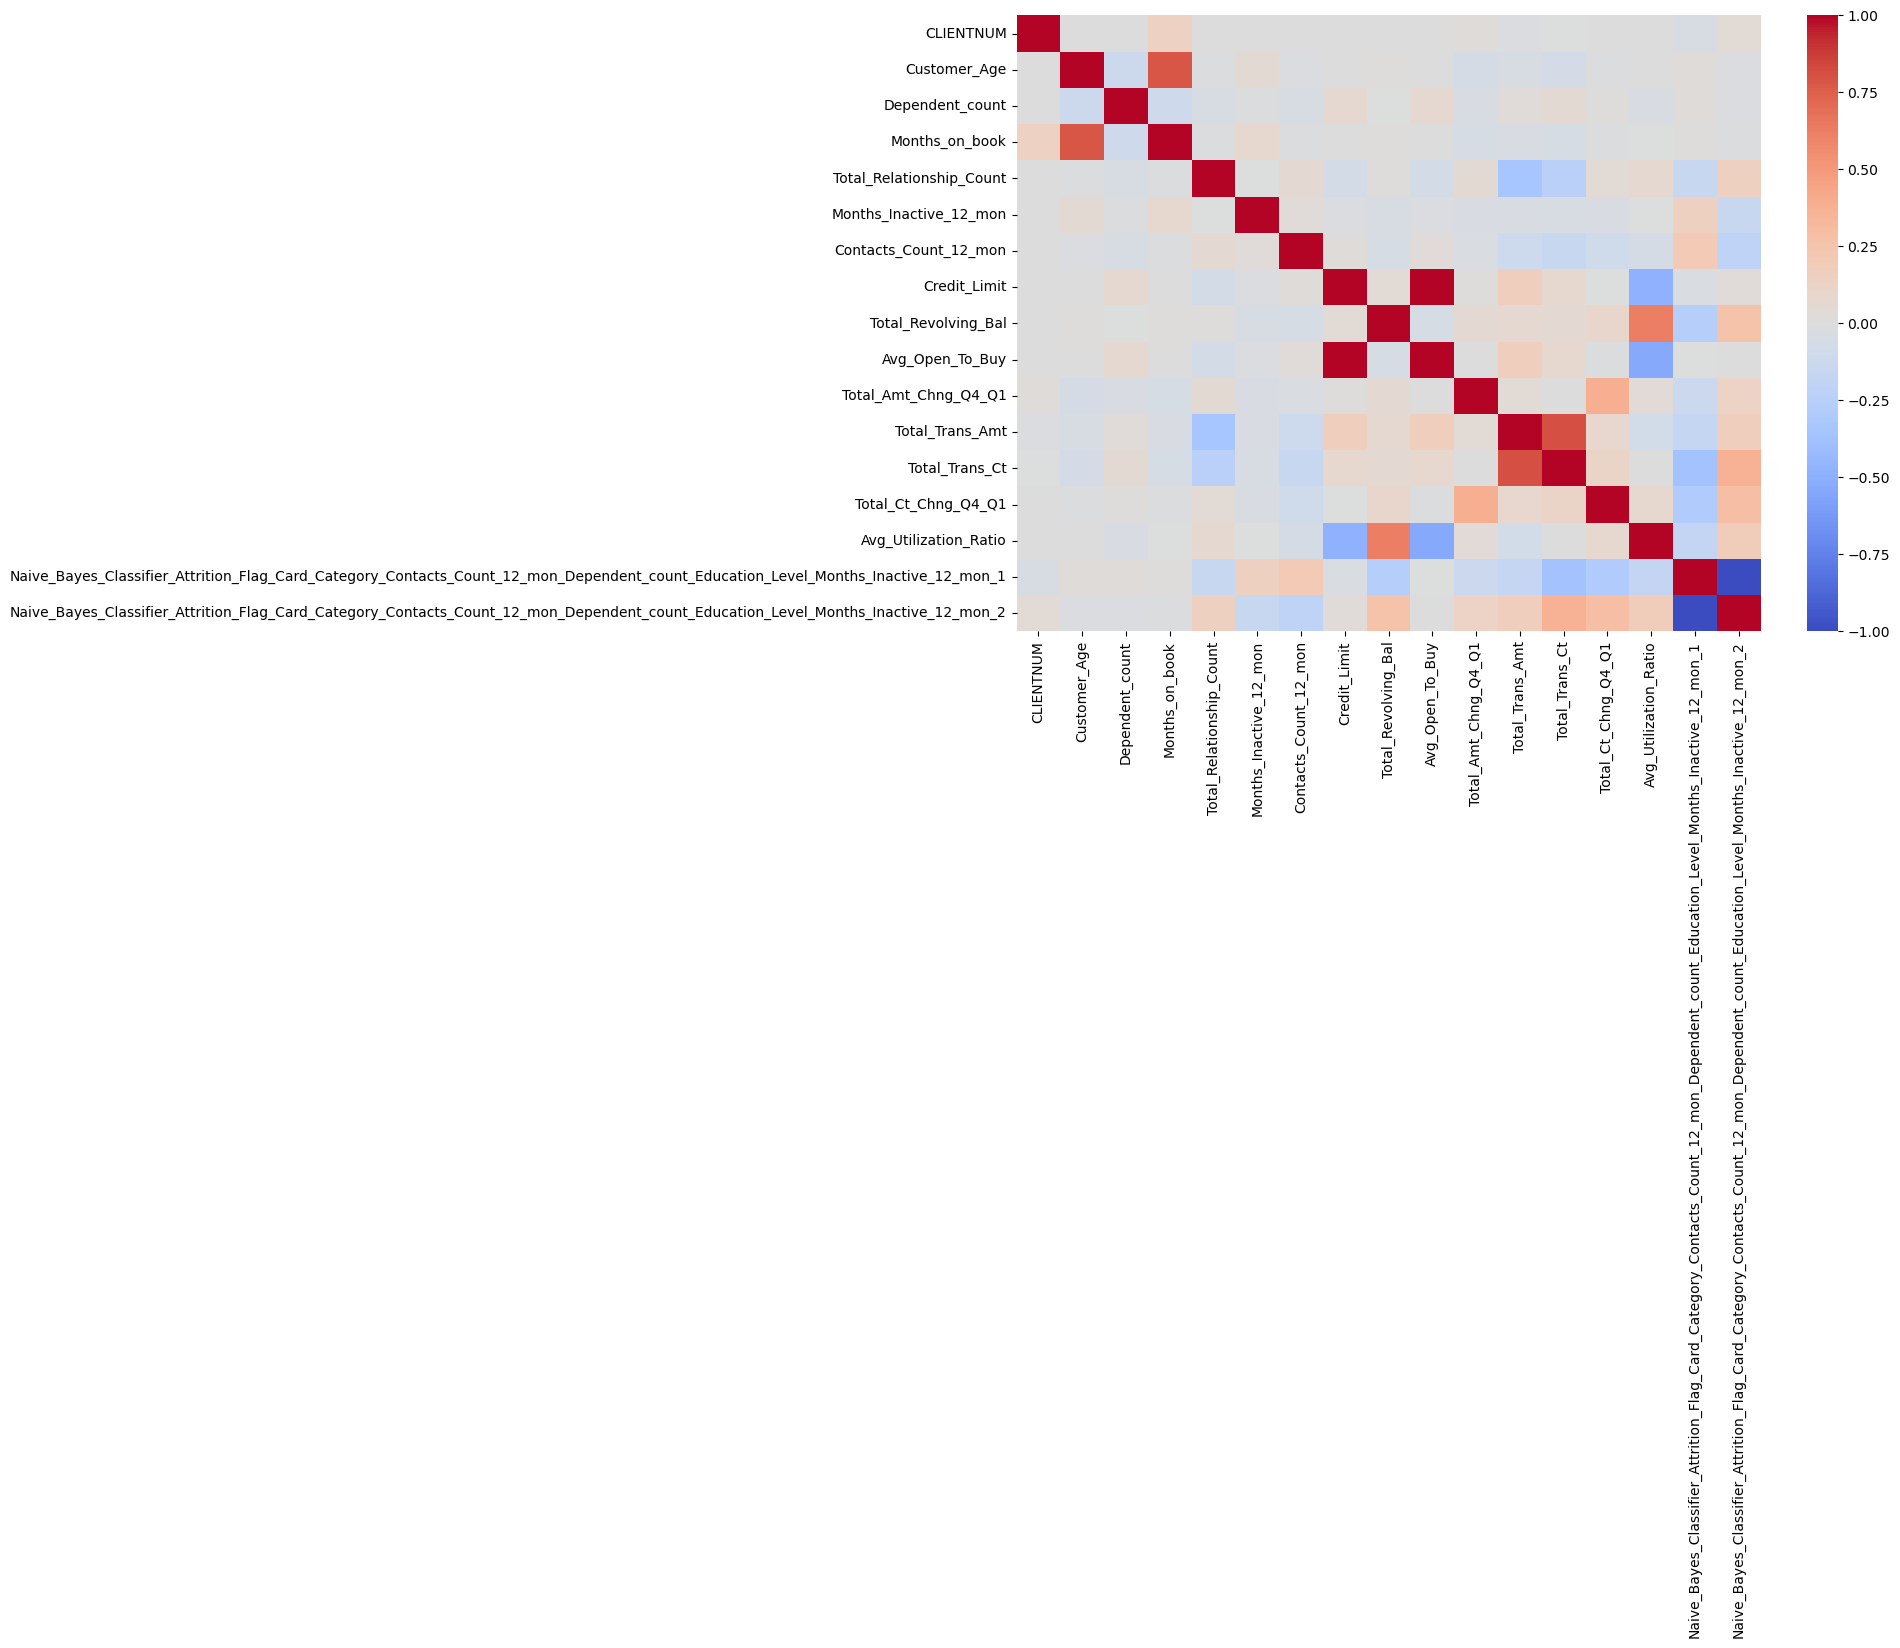

In [7]:
numeric_df = dataset.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.show()

## WHAT A CORRELATION HEATMAP SHOWS?

A heatmap displays the **correlation between numerical features**.

Correlation ranges from:

* **+1** → strong positive relationship
* **0** → no relationship
* **–1** → strong negative relationship

---

## HOW TO INTERPRET IT?

---
### 1. Look at the Color First

Most heatmaps use:

* 🔴 **Red (or warm colors)** → strong positive correlation
* 🔵 **Blue (or cool colors)** → strong negative correlation
* ⚪ **Neutral/light color** → weak or no correlation

---

### 2. Focus on Strong Relationships
Note:
> “Ignore small values — focus on correlations above 0.6 or below -0.6”

---

### Case 1: Strong Positive Correlation

```text
Total_Trans_Amt ↔ Total_Trans_Ct
```
Interpretation:

* Customers who **spend more** also **transact more frequently**

Business meaning:

> High-value, active customers

---

### Case 2: Strong Negative Correlation

```text
Months_Inactive_12_mon ↔ Total_Trans_Ct
```
Interpretation:

* More inactive months → fewer transactions

Business meaning:

> Potential churn risk

---

### Case 3: Near Zero Correlation

```text
Credit_Limit ↔ Total_Trans_Ct
```
Interpretation:

* Credit limit does NOT strongly affect how often customers transact
Insight:

> Having money ≠ using it

---

### 3. Detect Redundant Features (VERY IMPORTANT)

If two features are highly correlated:

```text
Credit_Limit ↔ Avg_Open_To_Buy
```

They contain **similar information**

> “We don’t need both — this can affect clustering quality”

---

### 4. Identify Useful Clustering Features

Good clustering features:
Have:

* High variance
* Low redundancy
* Meaningful behavior

---
**Note**:
* Highly correlated features = redundant
* Independent features = useful

### WHAT IS VARIANCE?
Variance measures how much a feature spreads out (how much it changes).
* High variance → values are very different → useful for clustering
* Low variance → values are similar → not useful

In [8]:
# Low variance = useless for clustering
numeric_df = dataset.select_dtypes(include=['int64', 'float64'])
numeric_df.var().sort_values(ascending=False)

CLIENTNUM                                                                                                                             1.361889e+15
Avg_Open_To_Buy                                                                                                                       8.264056e+07
Credit_Limit                                                                                                                          8.260586e+07
Total_Trans_Amt                                                                                                                       1.154049e+07
Total_Revolving_Bal                                                                                                                   6.642044e+05
Total_Trans_Ct                                                                                                                        5.509616e+02
Customer_Age                                                                                                          

What we’ve printed is essentially feature variances, and they already tell us something critical:
* The dataset is severely unscaled (variance ranges from ~1e-2 to 1e15). Before clustering or PCA, this is a big `red flag`.

---

We want to visualize variance across features, but there's `Problem with this plot if not scaled` because our values span between `1e-2 → 1e15; hence, Small features will be invisible`.

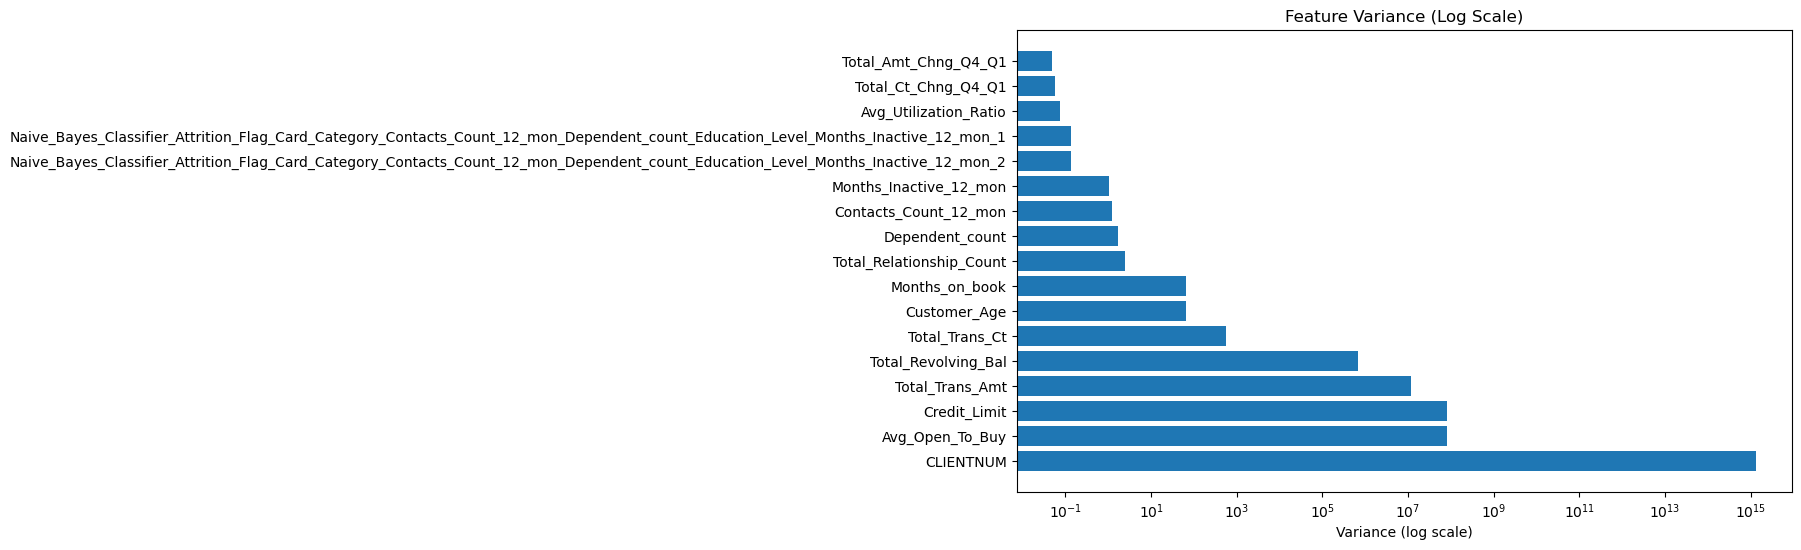

In [9]:
# Option 1: Log-scale bar plot
variance = numeric_df.var().sort_values(ascending=False)

plt.figure(figsize=(10,6))
plt.barh(variance.index, variance.values)
plt.xscale('log')
plt.title("Feature Variance (Log Scale)")
plt.xlabel("Variance (log scale)")
plt.show()

### What the above plot represents?
* Each bar = variance of a feature
* X-axis = log scale of variance

You’re comparing relative spread (importance in distance-based models).

---

### Key observations
1. Extreme dominance by a few features

Top features:
* CLIENTNUM (~10¹⁵)
* Avg_Open_To_Buy (~10⁸)
* Credit_Limit (~10⁸)
* Total_Trans_Amt (~10⁷)

Interpretation:
* These features have massively larger spread
* In distance-based models (KMeans, Agglomerative): `These features dominate cluster formation`, Especially: `CLIENTNUM is an ID column → completely meaningless for clustering`.

Let's group the features into 4 categories:
1. EXTREMELY HIGH VARIANCE (which we'll REMOVE)

**Example**: (CLIENTNUM)
- This is just an ID column

- It has huge variance because every value is unique

**Problem**:
- It will completely distort clustering.
---
2. VERY HIGH VARIANCE FEATURES (scaling required)
    * Credit_Limit           → 8.26e+07
    * Avg_Open_To_Buy        → 8.26e+07
    * Total_Trans_Amt        → 1.15e+07
    * Total_Revolving_Bal    → 6.64e+05

    These features dominate because their values are large. “Clustering uses distance — large numbers dominate distance”

   **Without scaling*, Model will focus ONLY on these features
---
3. MODERATE VARIANCE (Good FEATURES)
    * Total_Trans_Ct          → 550
    * Customer_Age            → 64
    * Months_on_book          → 63
   
   These are:
    * Informative
    * Balanced
    * Useful for clustering
---
4. LOW VARIANCE FEATURES (May be USELESS)
    * Avg_Utilization_Ratio → 0.076
    * Total_Ct_Chng_Q4_Q1   → 0.056
    * Total_Amt_Chng_Q4_Q1  → 0.048
      
Values don’t change much across customers. “If everyone is similar, the feature can’t separate clusters”

---
### Highly redundant financial features

We have:
* Credit_Limit
* Avg_Open_To_Buy
* Total_Revolving_Bal
  
**Relationship**: Credit_Limit ≈ Avg_Open_To_Buy + Total_Revolving_Bal. `These are strongly correlated`.

---

### From the little Observation we did, we now know that we're keeping:
- Credit_Limit
- Total_Revolving_Bal
- Total_Trans_Amt
- Total_Trans_Ct
- Customer_Age
- Months_on_book
- Total_Relationship_Count
- Dependent_count
- Contacts_Count_12_mon
- Months_Inactive_12_mon
- Avg_Utilization_Ratio

In [10]:
# Let's see if we can drop some more features, If correlation > 0.9 → we'll consider dropping one
dataset[['Total_Ct_Chng_Q4_Q1', 'Total_Amt_Chng_Q4_Q1']].corr()

,Total_Ct_Chng_Q4_Q1,Total_Amt_Chng_Q4_Q1
Total_Ct_Chng_Q4_Q1,1.000000,0.384189
Total_Amt_Chng_Q4_Q1,0.384189,1.000000


In [11]:
#Drop `CLIENTNUM` cloumn
dataset = dataset.drop([
    "CLIENTNUM",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1"
], axis=1)
dataset.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


Note; `Income_Category` can be useful — but only if handled correctly and with clear reasoning. Now let’s break it down:
**WHAT IS Income_Category?**

It looks like:

- Less than $40K
  
- $40K - $60K
  
- $60K - $80K
  
- $80K - $120K
  
- $120K +

- Unknown

This is an ordinal categorical feature (it has order).

---
### WHY IT CAN BE USEFUL?

Income influences:
- Spending power
- Credit usage
- Risk profile

So it helps answer:
| “Are high-income customers behaving differently?”

---
**BUT HERE’S THE CATCH**:

*Clustering algorithms*:
- Do NOT understand text
- Do NOT understand category order automatically, So if you do nothing `This will break or mislead the model`.

In [12]:
# Let's handle it using `Ordinal Encoding`
income_mapping = {
    'Less than $40K': 1,
    '$40K - $60K': 2,
    '$60K - $80K': 3,
    '$80K - $120K': 4,
    '$120K +': 5,
    'Unknown': 0
}
dataset['Income_Category'] = dataset['Income_Category'].map(income_mapping)

dataset.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,3,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,1,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,4,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,1,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,3,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


### Scaling?
*Scaling* in machine learning is a data pre-processing technique that transforms numerical features to a similar range or distribution. It prevents features with large magnitudes (e.g., salary) from dominating those with smaller magnitudes (e.g., age), ensuring models like KNN, SVM, and gradient descent algorithms perform accurately.

Note that; there are high-value features hidden by scale, not neccessary useless ones.

---
### Pipeline?
A machine learning pipeline is a structured, automated workflow that links data collection, preprocessing, feature engineering, modeling, and evaluation into a single, cohesive process. By standardizing these steps, pipelines simplify model development, improve efficiency, and enable scalable, reproducible machine learning projects.

In [13]:
dataset.shape

(10127, 20)

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [15]:
# Separate Numeric and Categorical Columns
num_cols = dataset.select_dtypes(include=['int64', 'float64']).columns
cat_cols = dataset.select_dtypes(include=['object', 'string']).columns

# Preprocessing
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop="first"), cat_cols)
])

# Transform
X_processed_scaled = preprocessor.fit_transform(dataset)

# Get correct feature names
feature_names = preprocessor.get_feature_names_out()

# Convert to DataFrame
X_scaled_df = pd.DataFrame(
    X_processed_scaled,
    columns=feature_names,
    index=dataset.index
)

X_scaled_df.head()

,num__Customer_Age,num__Dependent_count,num__Income_Category,num__Months_on_book,num__Total_Relationship_Count,num__Months_Inactive_12_mon,num__Contacts_Count_12_mon,num__Credit_Limit,num__Total_Revolving_Bal,num__Avg_Open_To_Buy,...,cat__Education_Level_High School,cat__Education_Level_Post-Graduate,cat__Education_Level_Uneducated,cat__Education_Level_Unknown,cat__Marital_Status_Married,cat__Marital_Status_Single,cat__Marital_Status_Unknown,cat__Card_Category_Gold,cat__Card_Category_Platinum,cat__Card_Category_Silver
0,-0.165406,0.503368,0.620039,0.384621,0.763943,-1.327136,0.492404,0.446622,-0.473422,0.488971,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.333570,2.043199,-0.736292,1.010715,1.407306,-1.327136,-0.411616,-0.041367,-0.366667,-0.008486,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.583058,0.503368,1.298204,0.008965,0.120579,-1.327136,-2.219655,-0.573698,-1.426858,-0.445658,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,-0.789126,1.273283,-0.736292,-0.241473,-0.522785,1.641478,-1.315636,-0.585251,1.661686,-0.734100,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-0.789126,0.503368,0.620039,-1.869317,0.763943,-1.327136,-2.219655,-0.430877,-1.426858,-0.302868,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [16]:
X_scaled_df.columns

Index(['num__Customer_Age', 'num__Dependent_count', 'num__Income_Category',
       'num__Months_on_book', 'num__Total_Relationship_Count',
       'num__Months_Inactive_12_mon', 'num__Contacts_Count_12_mon',
       'num__Credit_Limit', 'num__Total_Revolving_Bal', 'num__Avg_Open_To_Buy',
       'num__Total_Amt_Chng_Q4_Q1', 'num__Total_Trans_Amt',
       'num__Total_Trans_Ct', 'num__Total_Ct_Chng_Q4_Q1',
       'num__Avg_Utilization_Ratio', 'cat__Attrition_Flag_Existing Customer',
       'cat__Gender_M', 'cat__Education_Level_Doctorate',
       'cat__Education_Level_Graduate', 'cat__Education_Level_High School',
       'cat__Education_Level_Post-Graduate', 'cat__Education_Level_Uneducated',
       'cat__Education_Level_Unknown', 'cat__Marital_Status_Married',
       'cat__Marital_Status_Single', 'cat__Marital_Status_Unknown',
       'cat__Card_Category_Gold', 'cat__Card_Category_Platinum',
       'cat__Card_Category_Silver'],
      dtype='str')

In [17]:
# Manual Renaming
X_scaled_df.columns = (
    X_scaled_df.columns.str.replace(r'^(num__|cat__)', '', regex=True)
)
X_scaled_df.columns

Index(['Customer_Age', 'Dependent_count', 'Income_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Attrition_Flag_Existing Customer', 'Gender_M',
       'Education_Level_Doctorate', 'Education_Level_Graduate',
       'Education_Level_High School', 'Education_Level_Post-Graduate',
       'Education_Level_Uneducated', 'Education_Level_Unknown',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Unknown', 'Card_Category_Gold',
       'Card_Category_Platinum', 'Card_Category_Silver'],
      dtype='str')

In [18]:
X_scaled_df.head()

,Customer_Age,Dependent_count,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,...,Education_Level_High School,Education_Level_Post-Graduate,Education_Level_Uneducated,Education_Level_Unknown,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,-0.165406,0.503368,0.620039,0.384621,0.763943,-1.327136,0.492404,0.446622,-0.473422,0.488971,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.333570,2.043199,-0.736292,1.010715,1.407306,-1.327136,-0.411616,-0.041367,-0.366667,-0.008486,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.583058,0.503368,1.298204,0.008965,0.120579,-1.327136,-2.219655,-0.573698,-1.426858,-0.445658,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,-0.789126,1.273283,-0.736292,-0.241473,-0.522785,1.641478,-1.315636,-0.585251,1.661686,-0.734100,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-0.789126,0.503368,0.620039,-1.869317,0.763943,-1.327136,-2.219655,-0.430877,-1.426858,-0.302868,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


### Feature Engineering

In [19]:
# Let's do a bit of `Feature Engineering`
X_scaled_df['avg_transaction_value'] = X_scaled_df['Total_Trans_Amt'] / X_scaled_df['Total_Trans_Ct']
X_scaled_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Customer_Age                      10127 non-null  float64
 1   Dependent_count                   10127 non-null  float64
 2   Income_Category                   10127 non-null  float64
 3   Months_on_book                    10127 non-null  float64
 4   Total_Relationship_Count          10127 non-null  float64
 5   Months_Inactive_12_mon            10127 non-null  float64
 6   Contacts_Count_12_mon             10127 non-null  float64
 7   Credit_Limit                      10127 non-null  float64
 8   Total_Revolving_Bal               10127 non-null  float64
 9   Avg_Open_To_Buy                   10127 non-null  float64
 10  Total_Amt_Chng_Q4_Q1              10127 non-null  float64
 11  Total_Trans_Amt                   10127 non-null  float64
 12  Total_Trans_Ct 

In [20]:
X_scaled_df.head()

,Customer_Age,Dependent_count,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,...,Education_Level_Post-Graduate,Education_Level_Uneducated,Education_Level_Unknown,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver,avg_transaction_value
0,-0.165406,0.503368,0.620039,0.384621,0.763943,-1.327136,0.492404,0.446622,-0.473422,0.488971,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.985431
1,0.333570,2.043199,-0.736292,1.010715,1.407306,-1.327136,-0.411616,-0.041367,-0.366667,-0.008486,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.675168
2,0.583058,0.503368,1.298204,0.008965,0.120579,-1.327136,-2.219655,-0.573698,-1.426858,-0.445658,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.387704
3,-0.789126,1.273283,-0.736292,-0.241473,-0.522785,1.641478,-1.315636,-0.585251,1.661686,-0.734100,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.497988
4,-0.789126,0.503368,0.620039,-1.869317,0.763943,-1.327136,-2.219655,-0.430877,-1.426858,-0.302868,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.672623


### Final Selected Features

| Feature                | Why It Matters              |
| ---------------------- | --------------------------- |
| Total_Trans_Amt        | Captures spending power     |
| Total_Trans_Ct         | Captures usage frequency    |
| Credit_Limit           | Captures financial capacity |
| Avg_Utilization_Ratio  | Captures behavior pattern   |
| Months_Inactive_12_mon | Captures engagement         |
| Income_Category        | Captures Income category    |
|Total_Revolving_Bal     | Captoures the outstanding debt that rolls over month-to-month |

---
> “Feature importance in unsupervised learning is not given — it is **discovered**.”

# Model A: 
## Behavioral Clustering (Numeric Only); Focus on pure financial behavior

## FINAL SUMMARY
### Common Mistake to avoid:
* Use all features blindly
* Ignore meaning
* Skip scaling

### Correct mindset:
* Think first
* Analyze
* then model
---

To identify important features:
1. Understand the business problem
2. Interpret feature meanings
3. Analyze distributions & correlations
4. Remove low-value features
5. Validate experimentally




In [21]:
# Numeric Only
X_numeric_df = X_scaled_df.loc[
    :,
    [
        'Customer_Age',
        'Total_Trans_Ct',
        'Credit_Limit',
        'Avg_Utilization_Ratio',
        'Months_Inactive_12_mon',
        'Income_Category',
        'Total_Revolving_Bal',
        'avg_transaction_value'
    ]
]
X_numeric_df.head()

,Customer_Age,Total_Trans_Ct,Credit_Limit,Avg_Utilization_Ratio,Months_Inactive_12_mon,Income_Category,Total_Revolving_Bal,avg_transaction_value
0,-0.165406,-0.973895,0.446622,-0.775882,-1.327136,0.620039,-0.473422,0.985431
1,0.333570,-1.357340,-0.041367,-0.616276,-1.327136,-0.736292,-0.366667,0.675168
2,0.583058,-1.911206,-0.573698,-0.997155,-1.327136,1.298204,-1.426858,0.387704
3,-0.789126,-1.911206,-0.585251,1.759686,1.641478,-0.736292,1.661686,0.497988
4,-0.789126,-1.570365,-0.430877,-0.997155,-1.327136,0.620039,-1.426858,0.672623


`Income_Category`: That is not just another feature, it’s a demographic signal that can strongly influence:
- Credit usage
- Spending capacity
- Risk behavior

Dropping it may reduce the business interpretability of our clusters. So, we'll:

**Option 1**: Build TWO Models
- Model A: Behavioral Clustering (Numeric Only); Focus on pure financial behavior
- Model B: Enriched Clustering (Numeric + Categorical)
Add encoded Income_Category

Then compare:
* Cluster separation (silhouette)
* Business meaning
---
### Why This Matters?
Without Income:
- Clusters = “High spenders vs low spenders”

With Income:
- Clusters = “High-income high spenders” vs “Low-income high utilization (risk)”

That’s much more actionable

## Let's Define Our Evaluation Framework

For clustering, you mainly compare using:
- `Silhouette Score` is used which measures `How well-separated clusters are`.
- Inertia (ONLY for KMeans)
- Cluster Stability / Shape (visual + interpretation); Using PCA plots

In [22]:
# Prepare a Comparison Function
from sklearn.metrics import silhouette_score

def evaluate_model(name, labels, X):
    # Ignore noise labels for DBSCAN (-1)
    if len(set(labels)) > 1 and len(set(labels)) < len(X):
        score = silhouette_score(X, labels)
    else:
        score = -1

    return {
        "model": name,
        "silhouette_score": score,
        "n_clusters": len(set(labels)) - (1 if -1 in labels else 0)
    }

## Apply Clustering Models

We’ll use:
- KMeans
- Agglomerative
- DBSCAN

In [23]:
# KMeans
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
labels_km = kmeans.fit_predict(X_numeric_df)

results_1 = []
labels_store = {}

labels_store["KMeans"] = labels_km
results_1.append(evaluate_model("KMeans", labels_km, X_numeric_df))

In [24]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4)
labels_agg = agg.fit_predict(X_numeric_df)

labels_store["Agglomerative"] = labels_agg
results_1.append(evaluate_model("Agglomerative", labels_agg, X_numeric_df))

In [25]:
# DBSCAN
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=1.2, min_samples=5)
labels_db = db.fit_predict(X_numeric_df)

labels_store["DBSCAN"] = labels_db
results_1.append(evaluate_model("DBSCAN", labels_db, X_numeric_df))

## Evaluate Model A: (Numeric Columns Only)

In [26]:
# Compare Results
results_1_df = pd.DataFrame(results_1)
results_1_df.sort_values(by="silhouette_score", ascending=False)

,model,silhouette_score,n_clusters
1,Agglomerative,0.816226,4
0,KMeans,0.720087,4
2,DBSCAN,-0.105005,11


In [27]:
# Pick Best Model
best_model_name_1 = results_1_df.sort_values(
    by="silhouette_score",
    ascending=False
).iloc[0]["model"]

best_labels = labels_store[best_model_name_1]

## Visualization Model A: using PCA

In [28]:
kmeans_labels = kmeans.labels_
agg_labels = agg.labels_
dbscan_labels = db.labels_

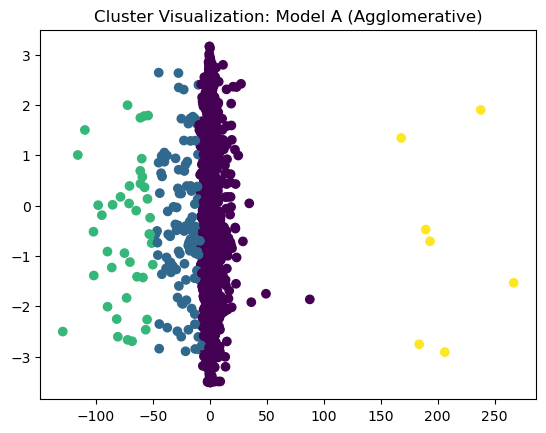

In [29]:
# PCA Visualization(`Agglomerative`)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_numeric_df)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels)
plt.title(f"Cluster Visualization: Model A ({best_model_name_1})")
plt.show()

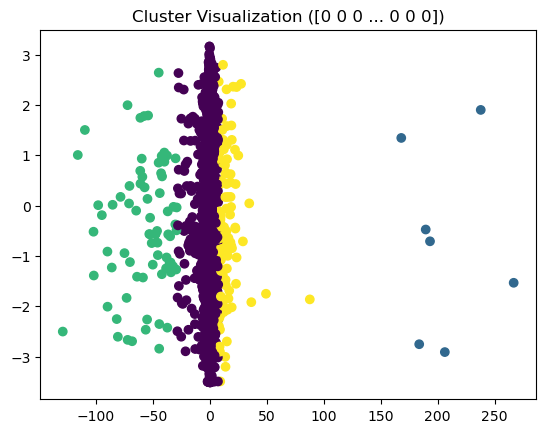

In [30]:
# PCA Visualization(K-Means)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_numeric_df)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels)
plt.title(f"Cluster Visualization ({labels_km})")
plt.show()

### What the vertical shape means
That narrow vertical band suggests:

* PC1 dominates separation
* Most clustering differences happen along x-axis
* PC2 (y-axis) contributes less to cluster separation

Translation:
* One combination of features (PC1) is doing most of the clustering work

## Business Interpretation

- Cluster 0: High volume buyers
- Cluster 1: Frequent small buyers
- Cluster 2: Irregular customers
- Cluster 3: Premium clients


# Model B: 
## Enriched Clustering (Numeric + Categorical) 

In [31]:
# KMeans
from sklearn.cluster import KMeans

kmeans_2 = KMeans(n_clusters=4, random_state=42)
labels_km_2 = kmeans_2.fit_predict(X_scaled_df)

results_2 = []
labels_store_2 = {}

labels_store_2["KMeans"] = labels_km_2
results_2.append(evaluate_model("KMeans", labels_km_2, X_scaled_df))

In [32]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

agg_2 = AgglomerativeClustering(n_clusters=4)
labels_2_agg = agg_2.fit_predict(X_scaled_df)

labels_store_2["Agglomerative"] = labels_2_agg
results_2.append(evaluate_model("Agglomerative", labels_2_agg, X_scaled_df))

In [33]:
# DBSCAN
from sklearn.cluster import DBSCAN

db_2 = DBSCAN(eps=1.2, min_samples=5)
labels_2_db = db_2.fit_predict(X_scaled_df)

labels_store_2["DBSCAN"] = labels_db
results_2.append(evaluate_model("DBSCAN", labels_2_db, X_scaled_df))

## Evaluate Model B: Enriched Clustering (Numeric + Categorical)

In [34]:
# Compare Results
results_2_df = pd.DataFrame(results_2)
results_2_df.sort_values(by="silhouette_score", ascending=False)

,model,silhouette_score,n_clusters
1,Agglomerative,0.835204,4
0,KMeans,0.091283,4
2,DBSCAN,-1.000000,0


In [35]:
# Pick Best Model
best_model_name_2 = results_2_df.sort_values(
    by="silhouette_score",
    ascending=False
).iloc[0]["model"]

best_labels_2 = labels_store_2[best_model_name_2]

## Visualization Model B: using PCA

In [36]:
kmeans_labels_2 = kmeans_2.labels_
agg_labels_2 = agg_2.labels_
dbscan_labels_2 = db_2.labels_

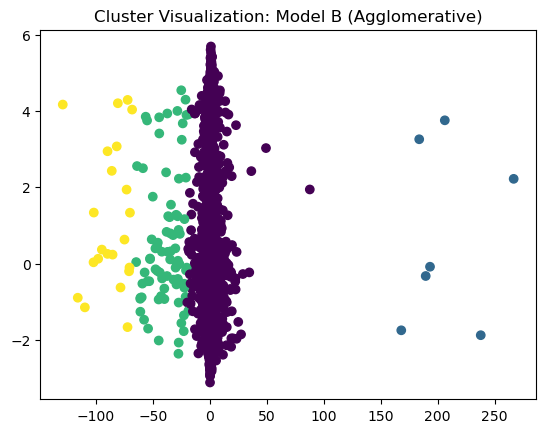

In [52]:
# PCA Visualization(`Agglomerative`)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_df)
x_reduced = X_pca

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels_2)
plt.title(f"Cluster Visualization: Model B ({best_model_name_2})")
plt.show()

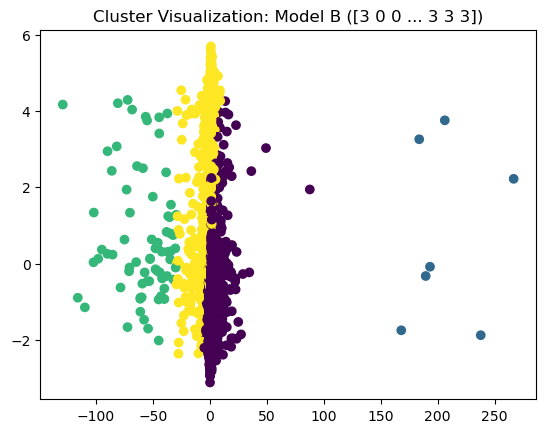

In [38]:
# PCA Visualization(K-Means)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_df)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels_2)
plt.title(f"Cluster Visualization: Model B ({labels_km_2})")
plt.show()

## Let's Compare both Models (A & B) and Evaluate

### Summary of the results (Model A: Numerical-only features)

| Model         | Silhouette | Interpretation       |
| ------------- | ---------- | -------------------- |
| Agglomerative | **0.816**  | Excellent separation |
| KMeans        | 0.720      | Good clustering      |
| DBSCAN        | -0.105     | Poor structure       |

This tells us that `the numeric features alone already contain strong cluster structure`.

---
### Summary of the results (Model B: Numerical + OneHotEncoded Categorical)

| Model         | Silhouette | Interpretation     |
| ------------- | ---------- | ------------------ |
| Agglomerative | **0.835**  | Slight improvement |
| KMeans        | **0.091**  | Clusters collapsed |
| DBSCAN        | **-1.0**   | Completely failed  |

This is the key signal: `Adding categorical features helped Agglomerative slightly, but broke KMeans and DBSCAN`.

## 🎯 Final Interpretation

Clustering using numerical features produced strong and well-separated clusters, indicating that the primary structure of the dataset is driven by continuous variables. When categorical features were introduced via one-hot encoding, Agglomerative clustering showed a slight improvement, suggesting that categorical variables add marginal refinement to cluster structure. However, KMeans and DBSCAN performance deteriorated significantly due to the high-dimensional sparsity introduced by one-hot encoding, which distorted distance calculations. PCA visualizations further confirmed that the dominant variance—and thus clustering signal—originates from numerical features, with categorical features contributing minimally to separability in reduced dimensions.

### Now the question is, How can you improve this `Agglomerative model`?

### Let's try to improve the `Agglomerative model`.
**Option 1**: Tune the linkage + distance metric: By default, `linkage="ward"`

Limitation:
- ward ONLY works with Euclidean distance
- Not ideal for mixed (numeric + categorical) data

Recommended baseline:`AgglomerativeClustering(n_clusters=4, linkage="average", metric="euclidean")`
OR: VERY powerful for this case; `AgglomerativeClustering(n_clusters=4, linkage="average", metric="manhattan")`

**Manhattan distance works better with**:
- sparse data (OHE)
- mixed feature types

**Option 2**: Try dimensionality reduction BEFORE clustering. Instead of clustering on full space:
- `pca = PCA(n_components=0.90)  # keep 90% variance,` 
- `X_reduced = pca.fit_transform(X_processed)` then fit e.g `AgglomerativeClustering(...).fit(X_reduced)`

**Benefits**:

- removes noise
- improves cluster separation
- stabilizes distances

### Define The `Baseline Model` (for comparison)

In [39]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

baseline_model = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"   # default
)

baseline_labels = baseline_model.fit_predict(X_scaled_df)

baseline_score = silhouette_score(X_scaled_df, baseline_labels)

print("Baseline Silhouette:", baseline_score)

Baseline Silhouette: 0.835203664945198


### OPTION 1: Improve Distance + Linkage
**Model 1A**: Average + Euclidean

In [40]:
model_euclidean = AgglomerativeClustering(
    n_clusters=4,
    linkage="average",
    metric="euclidean"
)

labels_euclidean = model_euclidean.fit_predict(X_scaled_df)

score_euclidean = silhouette_score(X_scaled_df, labels_euclidean)

print("Average + Euclidean:", score_euclidean)

Average + Euclidean: 0.9178507007296075


### OPTION 1: Improve Distance + Linkage
Model 1B: Average + Manhattan (IMPORTANT)

In [41]:
model_manhattan = AgglomerativeClustering(
    n_clusters=4,
    linkage="average",
    metric="manhattan"
 )

labels_manhattan = model_manhattan.fit_predict(X_scaled_df)

score_manhattan = silhouette_score(X_scaled_df, labels_manhattan)


print("Average + Manhattan:", score_manhattan)

Average + Manhattan: 0.8990341291218699


### OPTION 2: PCA Before Clustering

In [42]:
from sklearn.decomposition import PCA

# Keep 90% variance
pca = PCA(n_components=0.90, random_state=42)

X_reduced = pca.fit_transform(X_scaled_df)

print("Original shape:", X_scaled_df.shape)
print("Reduced shape:", X_reduced.shape)

Original shape: (10127, 30)
Reduced shape: (10127, 6)


### OPTION 2: PCA Before Clustering
Model 2A: PCA + Ward

In [43]:
model_pca_ward = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

labels_pca_ward = model_pca_ward.fit_predict(X_reduced)

score_pca_ward = silhouette_score(X_reduced, labels_pca_ward)

print("PCA + Ward:", score_pca_ward)

PCA + Ward: 0.8663289947838085


### OPTION 2: PCA Before Clustering
(PCA + Manhattan)

In [44]:
model_pca_manhattan = AgglomerativeClustering(
    n_clusters=4,
    linkage="average",
    metric="manhattan"
)

labels_pca_manhattan = model_pca_manhattan.fit_predict(X_reduced)

score_pca_manhattan = silhouette_score(X_reduced, labels_pca_manhattan)

print("PCA + Manhattan:", score_pca_manhattan)

PCA + Manhattan: 0.9204469633868335


## Compare All Results

In [45]:
results = pd.DataFrame({
    "Model": [
        "Baseline (Ward)",
        "Average + Euclidean",
        "Average + Manhattan",
        "PCA + Ward",
        "PCA + Manhattan"
    ],
    "Silhouette Score": [
        baseline_score,
        score_euclidean,
        score_manhattan,
        score_pca_ward,
        score_pca_manhattan
    ]
})

print(results.sort_values(by="Silhouette Score", ascending=False))

                 Model  Silhouette Score
4      PCA + Manhattan          0.920447
1  Average + Euclidean          0.917851
2  Average + Manhattan          0.899034
3           PCA + Ward          0.866329
0      Baseline (Ward)          0.835204


| Model               | Score     | Interpretation                  |
| ------------------- | --------- | ------------------------------- |
| **PCA + Manhattan** | **0.920** | Best structure                |
| Average + Euclidean | 0.918     | Very close second               |
| Average + Manhattan | 0.899     | Good but less stable            |
| PCA + Ward          | 0.866     | PCA helps, but distance matters |
| Baseline (Ward)     | 0.835     | weakest                         |

The improvement comes from two separate effects working together:

1. **PCA effect**
- removed noise
- reduced dimensionality from OHE explosion
- improved cluster compactness

2. **Manhattan distance effect**
- handles sparse binary features better than Euclidean
- more robust to high-dimensional geometry

## Visualize (Using PCA 2D for consistency)

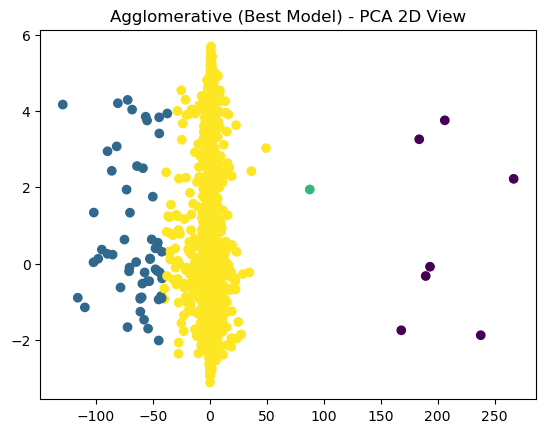

In [46]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce to 2D for plotting
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled_df)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_manhattan)
plt.title("Agglomerative (Best Model) - PCA 2D View")
plt.show()

## FINAL model

In [47]:
model_pca_manhattan = AgglomerativeClustering(
    n_clusters=4,
    linkage="average",
    metric="manhattan"
)

labels_pca_manhattan = model_pca_manhattan.fit_predict(X_reduced)

score_pca_manhattan = silhouette_score(X_reduced, labels_pca_manhattan)

print("PCA + Manhattan:", score_pca_manhattan)

PCA + Manhattan: 0.9204469633868335


## SAVE YOUR MODEL!

In [54]:
from joblib import dump
import numpy as np

model = AgglomerativeClustering(n_clusters=4)
labels = model.fit_predict(x_reduced)

dump({
    "preprocessor": preprocessor,
    "pca": pca,
    "model": model,
    "centroids": np.vstack([
        x_reduced[labels == i].mean(axis=0) 
        for i in range(4)])
}, "final_clustering_pipeline.joblib")

['final_clustering_pipeline.joblib']

In [55]:
# 1. Initialize and fit your model
model = AgglomerativeClustering(n_clusters=3)
model.fit_predict(X_reduced)

# 2. Save the model to a file
joblib.dump(model, 'agglomerative_model.joblib')

['agglomerative_model.joblib']

## Prediction function

In [ ]:
from joblib import load
from sklearn.metrics.pairwise import pairwise_distances

bundle = load("final_clustering_pipeline.joblib")

preprocessor = bundle["preprocessor"]
pca = bundle["pca"]
centroids = bundle["centroids"]

def predict_cluster(X_new):
    X_proc = preprocessor.transform(X_new)
    X_red = pca.transform(X_proc)

    distances = pairwise_distances(X_red, centroids, metric="manhattan")
    return distances.argmin(axis=1)

## Interpret clusters

In [ ]:
df["cluster"] = labels

# Numeric profiling
profile_num = df.groupby("cluster")[num_cols].mean()

# Categorical profiling
profile_cat = df.groupby("cluster")[cat_cols].agg(lambda x: x.value_counts().index[0])